In [519]:
#import the libraries needed for the project
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [520]:
# Load the excel csv
df = pd.read_csv('Bengaluru_House_Data.csv')

In [521]:
df.head()

,area_type,availability,location,size,society,total_sqft,bath,balcony,price
0,Super built-up Area,19-Dec,Electronic City Phase II,2 BHK,Coomee,1056,2.0,1.0,39.07
1,Plot Area,Ready To Move,Chikka Tirupathi,4 Bedroom,Theanmp,2600,5.0,3.0,120.00
2,Built-up Area,Ready To Move,Uttarahalli,3 BHK,NaN,1440,2.0,3.0,62.00
3,Super built-up Area,Ready To Move,Lingadheeranahalli,3 BHK,Soiewre,1521,3.0,1.0,95.00
4,Super built-up Area,Ready To Move,Kothanur,2 BHK,NaN,1200,2.0,1.0,51.00


In [522]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13320 entries, 0 to 13319
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   area_type     13320 non-null  object 
 1   availability  13320 non-null  object 
 2   location      13319 non-null  object 
 3   size          13304 non-null  object 
 4   society       7818 non-null   object 
 5   total_sqft    13320 non-null  object 
 6   bath          13247 non-null  float64
 7   balcony       12711 non-null  float64
 8   price         13320 non-null  float64
dtypes: float64(3), object(6)
memory usage: 936.7+ KB


In [523]:
df.shape

(13320, 9)

In [524]:
df.describe()

,bath,balcony,price
count,13247.000000,12711.000000,13320.000000
mean,2.692610,1.584376,112.565627
std,1.341458,0.817263,148.971674
min,1.000000,0.000000,8.000000
25%,2.000000,1.000000,50.000000
50%,2.000000,2.000000,72.000000
75%,3.000000,2.000000,120.000000
max,40.000000,3.000000,3600.000000


In [525]:
df.isnull().sum().sort_values(ascending=False)
(df.isnull().sum().sort_values(ascending=False) / len(df)) * 100

society         41.306306
balcony          4.572072
bath             0.548048
size             0.120120
location         0.007508
area_type        0.000000
availability     0.000000
total_sqft       0.000000
price            0.000000
dtype: float64

In [526]:
df = df.drop(columns=["society", "availability"])

In [527]:
df["bath"].value_counts()

bath
2.0     6908
3.0     3286
4.0     1226
1.0      788
5.0      524
6.0      273
7.0      102
8.0       64
9.0       43
10.0      13
12.0       7
13.0       3
11.0       3
16.0       2
27.0       1
40.0       1
15.0       1
14.0       1
18.0       1
Name: count, dtype: int64

In [528]:
df.nunique()

area_type        4
location      1305
size            31
total_sqft    2117
bath            19
balcony          4
price         1994
dtype: int64

In [529]:
df["size"].value_counts().head(10)

size
2 BHK        5199
3 BHK        4310
4 Bedroom     826
4 BHK         591
3 Bedroom     547
1 BHK         538
2 Bedroom     329
5 Bedroom     297
6 Bedroom     191
1 Bedroom     105
Name: count, dtype: int64

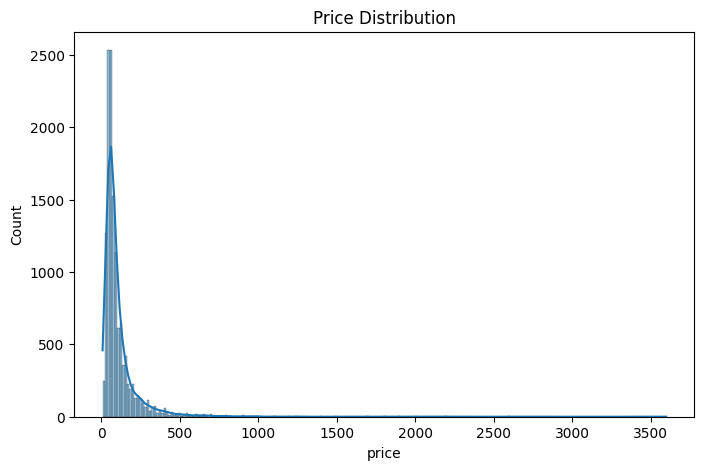

In [530]:
plt.figure(figsize=(8,5))
sns.histplot(df["price"], kde=True)
plt.title("Price Distribution")
plt.show()

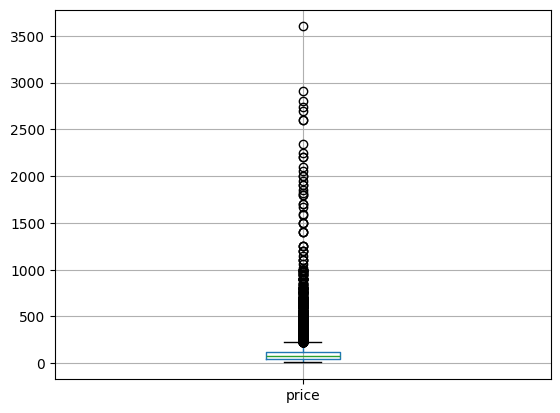

In [531]:
df.boxplot(column="price")
plt.show()

In [532]:
df["size"].unique()

array(['2 BHK', '4 Bedroom', '3 BHK', '4 BHK', '6 Bedroom', '3 Bedroom',
       '1 BHK', '1 RK', '1 Bedroom', '8 Bedroom', '2 Bedroom',
       '7 Bedroom', '5 BHK', '7 BHK', '6 BHK', '5 Bedroom', '11 BHK',
       '9 BHK', nan, '9 Bedroom', '27 BHK', '10 Bedroom', '11 Bedroom',
       '10 BHK', '19 BHK', '16 BHK', '43 Bedroom', '14 BHK', '8 BHK',
       '12 Bedroom', '13 BHK', '18 Bedroom'], dtype=object)

In [533]:
df["bhk"] = df["size"].str.split().str[0].astype(float)
df = df.drop(columns=["size"])
df.head()

,area_type,location,total_sqft,bath,balcony,price,bhk
0,Super built-up Area,Electronic City Phase II,1056,2.0,1.0,39.07,2.0
1,Plot Area,Chikka Tirupathi,2600,5.0,3.0,120.00,4.0
2,Built-up Area,Uttarahalli,1440,2.0,3.0,62.00,3.0
3,Super built-up Area,Lingadheeranahalli,1521,3.0,1.0,95.00,3.0
4,Super built-up Area,Kothanur,1200,2.0,1.0,51.00,2.0


In [534]:
df = df[df["bath"] <= df["bhk"] + 2]

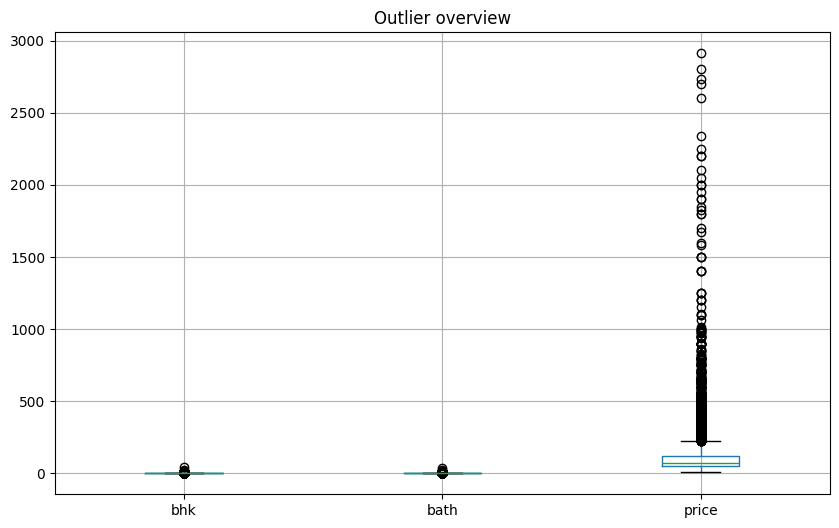

In [535]:
df[["total_sqft","bhk","bath","price"]].boxplot(figsize=(10,6))
plt.title("Outlier overview")
plt.show()

In [536]:
df.describe()

,bath,balcony,price,bhk
count,13231.000000,12703.000000,13231.000000,13231.000000
mean,2.683924,1.584114,111.576441,2.797597
std,1.315762,0.817069,143.283781,1.288063
min,1.000000,0.000000,8.000000,1.000000
25%,2.000000,1.000000,50.000000,2.000000
50%,2.000000,2.000000,71.950000,3.000000
75%,3.000000,2.000000,120.000000,3.000000
max,40.000000,3.000000,2912.000000,43.000000


In [537]:
# Step 3: Clean 'location' - Strip spaces, handle missing, group rare locations
df['location'] = df['location'].apply(lambda x: str(x).strip() if pd.notnull(x) else np.nan)
# Drop rows with missing location (few)
df = df.dropna(subset=['location'])
# Group rare locations (<=10 occurrences) into 'Other'
loc_stats = df['location'].value_counts()
df['location'] = df['location'].apply(lambda x: x if loc_stats[x] > 10 else 'Other')

In [538]:
df['location'].value_counts()

location
Other               2873
Whitefield           535
Sarjapur  Road       392
Electronic City      303
Kanakpura Road       266
                    ... 
Nehru Nagar           11
Thyagaraja Nagar      11
Nagasandra            11
HAL 2nd Stage         11
Banjara Layout        11
Name: count, Length: 242, dtype: int64

Total Unique Values: 2064
Sample Unique Values: ['1056' '2600' '1440' '1521' '1200' '1170' '2732' '3300' '1310' '1020']

1. Pure Numbers (Count: 1891 )
Examples: ['1056', '2600', '1440', '1521', '1200', '1170', '2732', '3300', '1310', '1020']

2. Ranges (Count: 128 )
Examples: ['2100 - 2850', '3067 - 8156', '1042 - 1105', '1145 - 1340', '1015 - 1540', '1195 - 1440', '1120 - 1145', '3090 - 5002', '1160 - 1195', '1115 - 1130']

3. Units/Non-Standard (Count: 45 )
All (since few): ['34.46Sq. Meter', '4125Perch', '1000Sq. Meter', '1100Sq. Yards', '5.31Acres', '30Acres', '716Sq. Meter', '1500Sq. Meter', '142.61Sq. Meter', '1574Sq. Yards', '361.33Sq. Yards', '117Sq. Yards', '3040Sq. Meter', '500Sq. Yards', '167Sq. Meter', '315Sq. Yards', '3Cents', '188.89Sq. Yards', '204Sq. Meter', '45Sq. Yards', '133.3Sq. Yards', '78.03Sq. Meter', '122Sq. Yards', '84.53Sq. Meter', '2.09Acres', '24Guntha', '697Sq. Meter', '1500Cents', '132Sq. Yards', '2Acres', '1100Sq. Meter', '15Acres', '1.26Acres', '151.11S

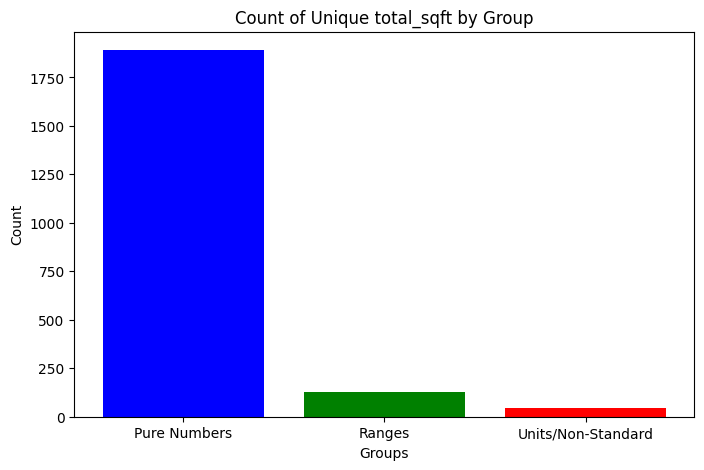

In [539]:
import re
# Step 2: Get unique values from 'total_sqft'
unique_sqft = df['total_sqft'].unique()
print(f"Total Unique Values: {len(unique_sqft)}")
print("Sample Unique Values:", unique_sqft[:10])  # Print first 10 for preview

# Step 3: Group unique values into categories
pure_numbers = []
ranges = []
units = []

for val in unique_sqft:
    val_str = str(val).strip()
    if re.match(r'^\d+(\.\d+)?$', val_str):  # Pure number (int or float)
        pure_numbers.append(val_str)
    elif '-' in val_str and re.match(r'^\d+(\.\d+)?\s*-\s*\d+(\.\d+)?$', val_str):  # Range like '1000 - 1200'
        ranges.append(val_str)
    else:  # Remaining with units or non-standard
        units.append(val_str)

# Step 4: Print the grouped uniques
print("\n1. Pure Numbers (Count:", len(pure_numbers), ")")
print("Examples:", pure_numbers[:10] if pure_numbers else "None")

print("\n2. Ranges (Count:", len(ranges), ")")
print("Examples:", ranges[:10] if ranges else "None")

print("\n3. Units/Non-Standard (Count:", len(units), ")")
print("All (since few):", units if units else "None")

# Step 5: Visualization - Bar chart of group counts
groups = ['Pure Numbers', 'Ranges', 'Units/Non-Standard']
counts = [len(pure_numbers), len(ranges), len(units)]

plt.figure(figsize=(8, 5))
plt.bar(groups, counts, color=['blue', 'green', 'red'])
plt.title('Count of Unique total_sqft by Group')
plt.xlabel('Groups')
plt.ylabel('Count')
plt.show()

In [540]:
# Print initial describe for reference
print("Initial 'total_sqft' Describe (as string):")
print(df['total_sqft'].describe())

Initial 'total_sqft' Describe (as string):
count     13230
unique     2064
top        1200
freq        840
Name: total_sqft, dtype: object


In [541]:
def clean_total_sqft(x, log_unparsed=False):
    """
    Convert total_sqft into a numeric value in square feet.
    Handles ranges and common Indian real-estate units.
    """
    if pd.isnull(x):
        return np.nan

    original_x = x
    x = str(x).strip().lower().replace(' ', '')

    # Handle ranges like "2100-2850"
    if '-' in x:
        try:
            a, b = x.split('-')
            return (float(a) + float(b)) / 2
        except:
            if log_unparsed:
                print(f"Unparsable range: {original_x}")
            return np.nan

    # Extract number + unit
    match = re.match(r'(\d+(\.\d+)?)(.*)', x)
    if not match:
        if log_unparsed:
            print(f"Unparsable: {original_x}")
        return np.nan

    value = float(match.group(1))
    unit = match.group(3)

    # Unit conversion map (to sqft)
    conversion_factors = {
        'sqmeter': 10.7639,
        'sqm': 10.7639,
        'sqyard': 9.0,
        'yard': 9.0,
        'acre': 43560,
        'cent': 435.6,
        'guntha': 1089,
        'ground': 2400,
        'perch': 272.25
    }

    for key, factor in conversion_factors.items():
        if key in unit:
            return value * factor

    # If no unit → assume sqft
    return value
df['total_sqft'] = df['total_sqft'].apply(clean_total_sqft)
df = df[df['total_sqft'].notna()]

In [542]:
df.describe()

,total_sqft,bath,balcony,price,bhk
count,1.323000e+04,13230.000000,12702.000000,13230.000000,13230.000000
mean,1.900398e+03,2.683900,1.584081,111.578374,2.797581
std,1.733193e+04,1.315809,0.817093,143.289024,1.288110
min,1.000000e+00,1.000000,0.000000,8.000000,1.000000
25%,1.100000e+03,2.000000,1.000000,50.000000,2.000000
50%,1.275000e+03,2.000000,2.000000,71.920000,3.000000
75%,1.674000e+03,3.000000,2.000000,120.000000,3.000000
max,1.306800e+06,40.000000,3.000000,2912.000000,43.000000


In [543]:
df["total_sqft"].value_counts()

total_sqft
1200.0    840
1100.0    222
1500.0    204
2400.0    195
600.0     180
         ... 
1922.0      1
2370.0      1
5.0         1
1004.0      1
4689.0      1
Name: count, Length: 1998, dtype: int64

In [544]:
df['total_sqft'].min()

np.float64(1.0)

In [545]:
df['total_sqft'].max()

np.float64(1306800.0)

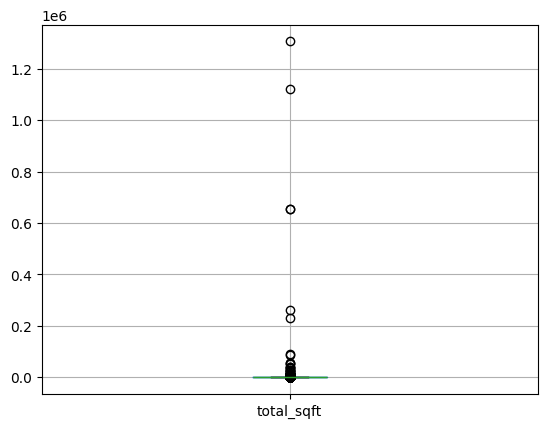

In [546]:
df.boxplot(column="total_sqft")
plt.show()

In [547]:
df.head()

,area_type,location,total_sqft,bath,balcony,price,bhk
0,Super built-up Area,Electronic City Phase II,1056.0,2.0,1.0,39.07,2.0
1,Plot Area,Chikka Tirupathi,2600.0,5.0,3.0,120.00,4.0
2,Built-up Area,Uttarahalli,1440.0,2.0,3.0,62.00,3.0
3,Super built-up Area,Lingadheeranahalli,1521.0,3.0,1.0,95.00,3.0
4,Super built-up Area,Kothanur,1200.0,2.0,1.0,51.00,2.0


In [548]:
# Feature engineering: Price per sqft (for outlier detection or as feature)
df['price_per_sqft'] = df['price'] * 100000 / df['total_sqft']  # Price in lakhs -> rupees
# Remove extreme price_per_sqft outliers (e.g., via IQR)
Q1 = df['price_per_sqft'].quantile(0.25)
Q3 = df['price_per_sqft'].quantile(0.75)
IQR = Q3 - Q1
df = df[(df['price_per_sqft'] >= Q1 - 1.5 * IQR) & (df['price_per_sqft'] <= Q3 + 1.5 * IQR)]

In [549]:
def remove_pps_outliers(df):
    df_out = pd.DataFrame()
    for loc, sub in df.groupby("location"):
        m = sub["price_per_sqft"].mean()
        st = sub["price_per_sqft"].std()
        reduced = sub[(sub["price_per_sqft"] > (m-st)) & (sub["price_per_sqft"] < (m+st))]
        df_out = pd.concat([df_out, reduced])
    return df_out

df = remove_pps_outliers(df)

In [550]:
df = df[df["total_sqft"]/df["bhk"] >= 300]

In [551]:
# Drop temp column if not using as feature
df = df.drop(['price_per_sqft'], axis=1)

In [552]:
df.head()

,area_type,location,total_sqft,bath,balcony,price,bhk
4991,Super built-up Area,1st Block Jayanagar,1000.0,3.0,2.0,60.0,2.0
8507,Super built-up Area,1st Block Jayanagar,1760.0,3.0,NaN,115.0,3.0
936,Super built-up Area,1st Phase JP Nagar,2825.0,4.0,3.0,250.0,4.0
2106,Super built-up Area,1st Phase JP Nagar,1875.0,3.0,1.0,167.0,3.0
3481,Super built-up Area,1st Phase JP Nagar,2024.0,3.0,NaN,157.0,3.0


In [553]:
from sklearn.model_selection import train_test_split

# Create price categories (bins based on quantiles or custom)
df['price_cat'] = pd.cut(df['price'], bins=[0, 50, 100, 200, 500, np.inf], 
                         labels=['very_low', 'low', 'medium', 'high', 'very_high'])
df['price_cat'].value_counts()

price_cat
low          4657
very_low     2427
medium       1371
high          264
very_high      11
Name: count, dtype: int64

In [554]:
df.head(10)

,area_type,location,total_sqft,bath,balcony,price,bhk,price_cat
4991,Super built-up Area,1st Block Jayanagar,1000.0,3.0,2.0,60.0,2.0,low
8507,Super built-up Area,1st Block Jayanagar,1760.0,3.0,NaN,115.0,3.0,medium
936,Super built-up Area,1st Phase JP Nagar,2825.0,4.0,3.0,250.0,4.0,high
2106,Super built-up Area,1st Phase JP Nagar,1875.0,3.0,1.0,167.0,3.0,medium
3481,Super built-up Area,1st Phase JP Nagar,2024.0,3.0,NaN,157.0,3.0,medium
4605,Super built-up Area,1st Phase JP Nagar,1394.0,2.0,1.0,100.0,2.0,low
5497,Super built-up Area,1st Phase JP Nagar,1077.0,2.0,2.0,93.0,2.0,low
6465,Super built-up Area,1st Phase JP Nagar,1590.0,3.0,3.0,131.0,3.0,medium
7416,Super built-up Area,1st Phase JP Nagar,2180.0,3.0,2.0,210.0,3.0,high
8299,Super built-up Area,1st Phase JP Nagar,1180.0,2.0,2.0,88.5,2.0,low


<Axes: >

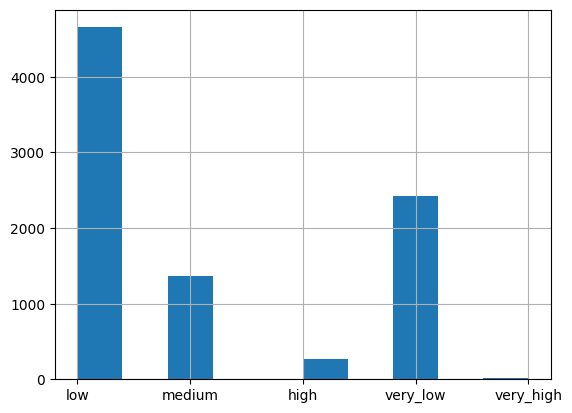

In [555]:
df['price_cat'].hist()

In [556]:
#Using the modern in-built function
from sklearn.model_selection import train_test_split
train_set, test_set = train_test_split(df, test_size=0.2, random_state=42)

In [557]:
#Stratified sampling to maintain same price proportions in both training and testing sets
from sklearn.model_selection import StratifiedShuffleSplit

split = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)

for train_idx, test_idx in split.split(df, df["price_cat"]):
    strat_train_set = df.iloc[train_idx].copy()
    strat_test_set = df.iloc[test_idx].copy()    # Use iloc for positional indices
#This ensures your test set is a fair mini version of your full dataset — balanced across price groups.  

In [558]:
# Drop price_cat after split
for set_ in (strat_train_set, strat_test_set):
    set_.drop("price_cat", axis=1, inplace=True)

In [559]:
#compare using the mean
df.groupby("price_cat", observed=True)["price"].mean()

price_cat
very_low      39.761139
low           70.789388
medium       133.501379
high         265.647727
very_high    838.090909
Name: price, dtype: float64

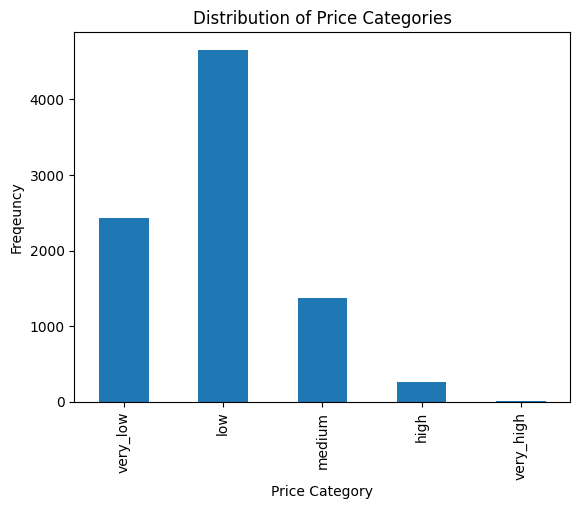

In [560]:
df["price_cat"].value_counts().sort_index().plot(kind="bar")
plt.xlabel("Price Category")
plt.ylabel("Freqeuncy")
plt.title("Distribution of Price Categories")
plt.show()

C:\Users\Engr Adigun\AppData\Local\Temp\ipykernel_11088\3402075352.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("price_cat")["price"].mean().plot(kind="bar")


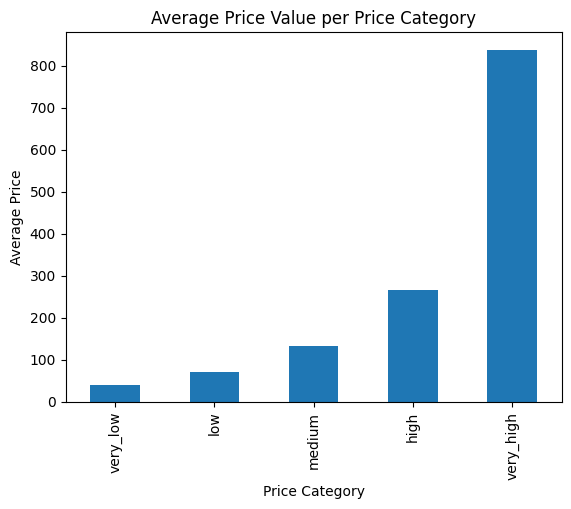

In [561]:
#Average house price per income category: This shows how income affects house prices
df.groupby("price_cat")["price"].mean().plot(kind="bar")
plt.xlabel("Price Category")
plt.ylabel("Average Price")
plt.title("Average Price Value per Price Category")
plt.show()

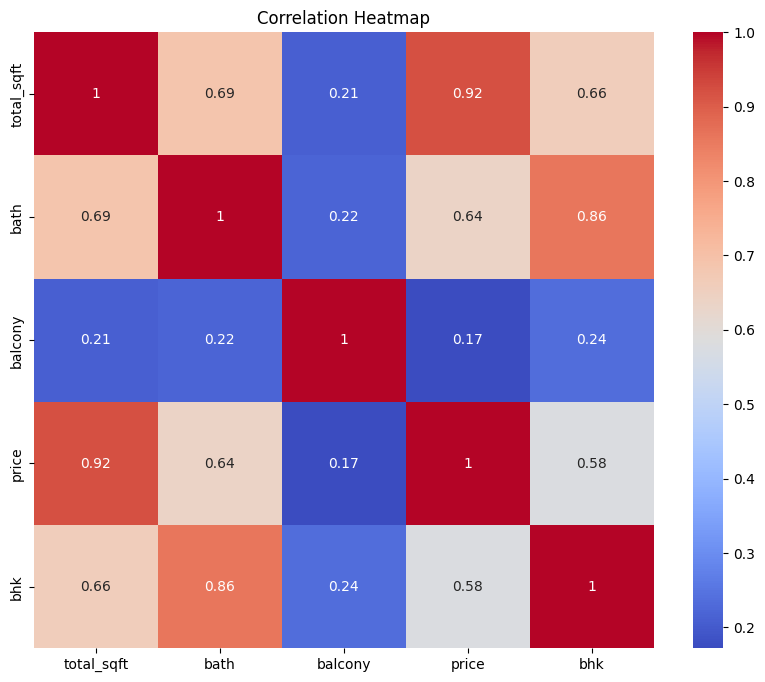

In [562]:
import seaborn as sns

corr = strat_train_set.corr(numeric_only=True)
plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

In [563]:
corr_matrix = df[["total_sqft", "bath", "balcony", "bhk", "price"]].corr()
corr_matrix["price"].sort_values(ascending=False)

price         1.000000
total_sqft    0.925841
bath          0.618882
bhk           0.566349
balcony       0.170005
Name: price, dtype: float64

In [564]:
# 2. Separate features and labels
# =====================
X_train = strat_train_set.drop("price", axis=1)
y_train = strat_train_set["price"].copy()

X_test = strat_test_set.drop("price", axis=1)
y_test = strat_test_set["price"].copy()

In [565]:
# Feature Engineering: Create ratio-based features
df['sqft_per_bhk'] = df['total_sqft'] / df['bhk']  # Space efficiency per bedroom
df['bath_per_bhk'] = df['bath'] / df['bhk']        # Bathroom density
df['balcony_per_bhk'] = df['balcony'] / df['bhk']  # Balcony density (minor impact)
df['price_per_sqft'] = (df['price'] * 100000) / df['total_sqft']  # Price in rupees per sqft (useful for correlations)

# Handle any infinities or NaNs from division (e.g., if bhk=0, though rare after cleaning)
df.replace([np.inf, -np.inf], np.nan, inplace=True)
df.fillna(df.median(numeric_only=True), inplace=True)  # Impute with median

# Verify new features
print(df[['sqft_per_bhk', 'bath_per_bhk', 'balcony_per_bhk', 'price_per_sqft']].describe())


       sqft_per_bhk  bath_per_bhk  balcony_per_bhk  price_per_sqft
count   8730.000000   8730.000000      8730.000000     8730.000000
mean     573.620374      0.964459         0.665646     5260.002221
std      185.211512      0.161644         0.331154     1342.499568
min      300.000000      0.333333         0.000000     2090.909091
25%      494.000000      1.000000         0.500000     4285.714286
50%      557.500000      1.000000         0.666667     5088.845101
75%      620.000000      1.000000         1.000000     6081.204350
max     7500.000000      2.000000         2.000000    11358.671909


In [566]:
df.describe()

,total_sqft,bath,balcony,price,bhk,sqft_per_bhk,bath_per_bhk,balcony_per_bhk,price_per_sqft
count,8730.000000,8730.000000,8730.000000,8730.000000,8730.000000,8730.000000,8730.000000,8730.000000,8730.000000
mean,1449.053919,2.412829,1.597022,78.871347,2.522337,573.620374,0.964459,0.665646,5260.002221
std,829.160958,0.911112,0.785094,58.341094,0.851175,185.211512,0.161644,0.331154,1342.499568
min,300.000000,1.000000,0.000000,10.000000,1.000000,300.000000,0.333333,0.000000,2090.909091
25%,1100.000000,2.000000,1.000000,49.000000,2.000000,494.000000,1.000000,0.500000,4285.714286
50%,1263.000000,2.000000,2.000000,65.000000,2.000000,557.500000,1.000000,0.666667,5088.845101
75%,1590.000000,3.000000,2.000000,90.000000,3.000000,620.000000,1.000000,1.000000,6081.204350
max,30400.000000,16.000000,3.000000,2100.000000,16.000000,7500.000000,2.000000,2.000000,11358.671909


In [567]:
df = df.drop(columns=["sqft_per_bhk","bath_per_bhk","balcony_per_bhk","price_per_sqft"])

In [568]:
from sklearn.base import BaseEstimator, TransformerMixin

#Numerical features in X are in this order: total_sqft, bath, balcony, bhk
# Adjust indices if your pipeline's numerical columns differ
total_sqft_ix, bath_ix, balcony_ix, bhk_ix = 0, 1, 2, 3

# 3. Custom Transformer
# =====================
class CombinedAttributesAdder(BaseEstimator, TransformerMixin):
    def __init__(self, add_balcony_per_bhk=True):
        self.add_balcony_per_bhk = add_balcony_per_bhk

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        sqft_per_bhk = X[:, 0] / X[:, 3]
        bath_per_bhk = X[:, 1] / X[:, 3]

        if self.add_balcony_per_bhk:
            balcony_per_bhk = X[:, 2] / X[:, 3]
            return np.c_[X, sqft_per_bhk, bath_per_bhk, balcony_per_bhk]
        else:
            return np.c_[X, sqft_per_bhk, bath_per_bhk]

In [579]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer

# 4. Pipelines
# =====================
num_attribs = ["total_sqft", "bath", "balcony", "bhk"]
cat_attribs = ["area_type", "location"]

num_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("attribs_adder", CombinedAttributesAdder()),
    ("scaler", StandardScaler()),
])

cat_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
])

full_pipeline = ColumnTransformer([
    ("num", num_pipeline, num_attribs),
    ("cat", cat_pipeline, cat_attribs),
])

In [580]:
df_prepared = full_pipeline.fit_transform(df)

print("Pipeline output shape:", df_prepared.shape)

#Convert to DataFrame


df_prepared_df = pd.DataFrame(df_prepared)

#Inspect Prepared Data

print("\nPrepared DataFrame Info:\n")
df_prepared_df.info()
df_prepared_df.isnull().sum().sort_values(ascending=False)

Pipeline output shape: (8730, 252)

Prepared DataFrame Info:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8730 entries, 0 to 8729
Columns: 252 entries, 0 to 251
dtypes: float64(252)
memory usage: 16.8 MB


0      0
173    0
160    0
161    0
162    0
      ..
88     0
89     0
90     0
91     0
251    0
Length: 252, dtype: int64

In [581]:
#Linear regression
from sklearn.linear_model import LinearRegression
# 5. Prepare data
# =====================
X_train_prepared = full_pipeline.fit_transform(X_train)
X_test_prepared = full_pipeline.transform(X_test)

In [582]:
# 6. Train model
# =====================
lin_reg = LinearRegression()
lin_reg.fit(X_train_prepared, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [583]:
#measuring how bad the linear regression is using RMSE
from sklearn.metrics import mean_squared_error
# 7. Evaluate properly
# =====================
y_pred = lin_reg.predict(X_test_prepared)

lin_mse = mean_squared_error(y_test, y_pred)
lin_rmse = np.sqrt(lin_mse)

print("Test RMSE:", lin_rmse)

Test RMSE: 16.018778909141112


In [574]:
from sklearn.pipeline import Pipeline

full_model = Pipeline([
    ("preprocessing", full_pipeline),
    ("model", LinearRegression())
])

In [575]:
from sklearn.model_selection import cross_val_score
from sklearn.metrics import mean_squared_error
import numpy as np

scores = cross_val_score(
    full_model,
    X_train,
    y_train,
    scoring="neg_mean_squared_error",
    cv=5
)

rmse_scores = np.sqrt(-scores)

print("RMSE scores:", rmse_scores)
print("Mean RMSE:", rmse_scores.mean())
print("Std deviation:", rmse_scores.std())

RMSE scores: [18.23839684 15.4929367  15.68000464 15.31321068 16.74731   ]
Mean RMSE: 16.294371772620334
Std deviation: 1.0924109791129497


In [576]:
from sklearn.metrics import mean_absolute_error,r2_score
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

In [578]:
r2

0.9385072187789167